In [1]:
import pandas as pd 
df = pd.read_csv('netflix_titles.csv')
print (df.shape)
# df.head()

# df.info()

# df.columns

# df.isnull().sum()

# df['type'].value_counts()

# df['rating'].value_counts()

# df['release_year'].value_counts()

# df.duplicated().sum()

(df.isnull().sum()/len(df))*100

(8807, 12)


show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [2]:
df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')
df['rating'] = df['rating'].fillna('unknown')

In [3]:
df = df.dropna(subset=['date_added'])
print(df.shape)

(8797, 12)


In [4]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('../dataset/netflix_titles.csv')

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create year and month columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Show output
df[['title', 'date_added', 'year_added', 'month_added']].head(10)

,title,date_added,year_added,month_added
0,Dick Johnson Is Dead,2021-09-25,2021.0,9.0
1,Blood & Water,2021-09-24,2021.0,9.0
2,Ganglands,2021-09-24,2021.0,9.0
3,Jailbirds New Orleans,2021-09-24,2021.0,9.0
4,Kota Factory,2021-09-24,2021.0,9.0
5,Midnight Mass,2021-09-24,2021.0,9.0
6,My Little Pony: A New Generation,2021-09-24,2021.0,9.0
7,Sankofa,2021-09-24,2021.0,9.0
8,The Great British Baking Show,2021-09-24,2021.0,9.0
9,The Starling,2021-09-24,2021.0,9.0


In [ ]:
movies = df[df['type'] == 'Movie'].copy()
shows = df[df['type'] == 'TV Show'].copy()

movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)
shows['seasons'] = shows['duration'].str.extract(r'(\d+)').astype(float)

print("Movies:", movies.shape)
print("Shows:", shows.shape)
print("\nSample movie durations:")
print(movies['duration_min'].describe())

In [ ]:
print(movies[movies['duration_min'] == 3][['title', 'duration_min']])
print(movies[movies['duration_min'] == 312][['title', 'duration_min']])

In [ ]:
df['genre'] = df['listed_in'].str.split(', ')
genre_df = df.explode('genre')

print("Original df rows:", len(df))
print("After explode rows:", len(genre_df))
genre_df['genre'].value_counts().head(10)

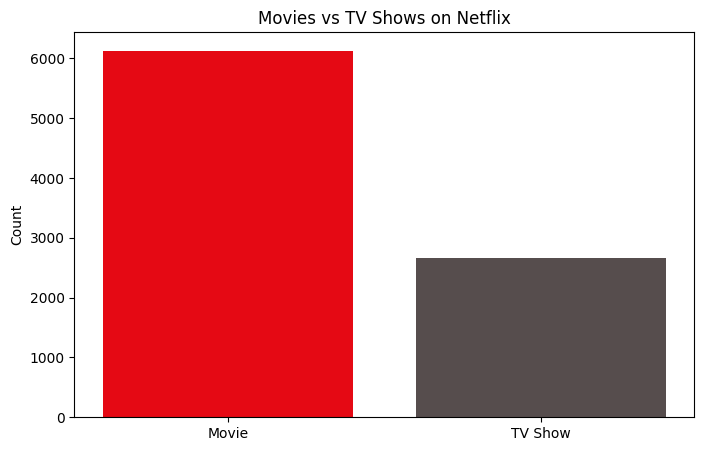

In [ ]:
import matplotlib.pyplot as plt
type_counts = df['type'].value_counts()
plt.figure(figsize=(8, 5))
colors = ['#E50914', '#564d4d']
plt.bar(type_counts.index, type_counts.values, color=colors)
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('Count')
plt.savefig('images/chart1_movies_vs_shows.png', bbox_inches='tight', dpi=150)
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('../dataset/netflix_titles.csv')

# Clean missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

# Convert date column properly
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Remove rows where date conversion failed
df = df.dropna(subset=['date_added'])

# Create new columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Split genres
df['genre'] = df['listed_in'].str.split(', ')

# Create exploded genre dataframe
genre_df = df.explode('genre')

# Print info
print("Ready! Shape:", df.shape)
print("Columns:", list(df.columns))

# Show sample data
print(df[['title', 'date_added', 'year_added', 'month_added']].head())

Ready! Shape: (8709, 15)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'genre']
                   title date_added  year_added  month_added
0   Dick Johnson Is Dead 2021-09-25        2021            9
1          Blood & Water 2021-09-24        2021            9
2              Ganglands 2021-09-24        2021            9
3  Jailbirds New Orleans 2021-09-24        2021            9
4           Kota Factory 2021-09-24        2021            9


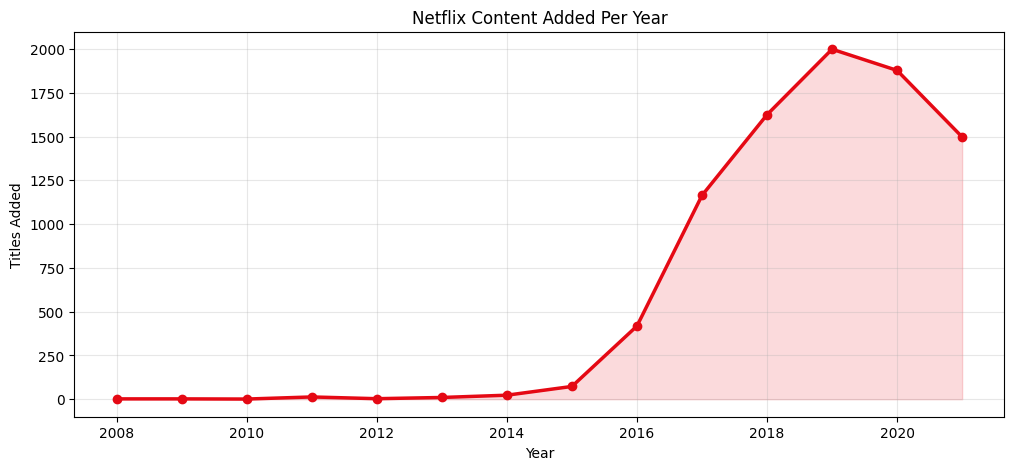

In [26]:
yearly = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly.values, color='#E50914', linewidth=2.5, marker='o')
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='#E50914')
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.grid(alpha=0.3)
plt.savefig('images/chart2_content_per_year.png', bbox_inches='tight', dpi=150)
plt.show()

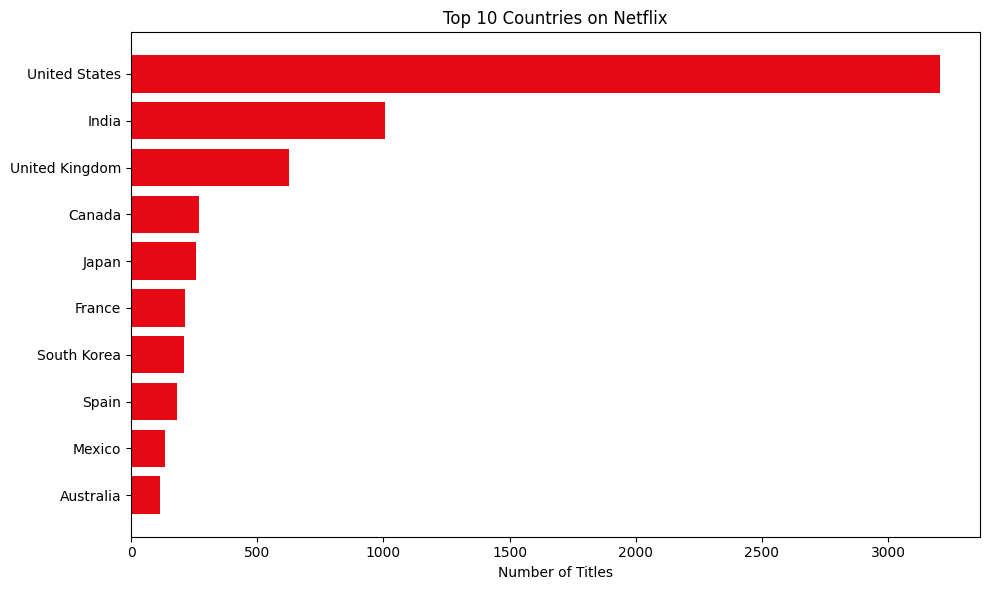

In [27]:
df['primary_country'] = df['country'].str.split(', ').str[0]

top_countries = (df[df['primary_country'] != 'Unknown']
                   ['primary_country'].value_counts().head(10))

plt.figure(figsize=(10, 6))
plt.barh(top_countries.index, top_countries.values, color='#E50914')
plt.title('Top 10 Countries on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/chart3_top_countries.png', bbox_inches='tight', dpi=150)
plt.show()

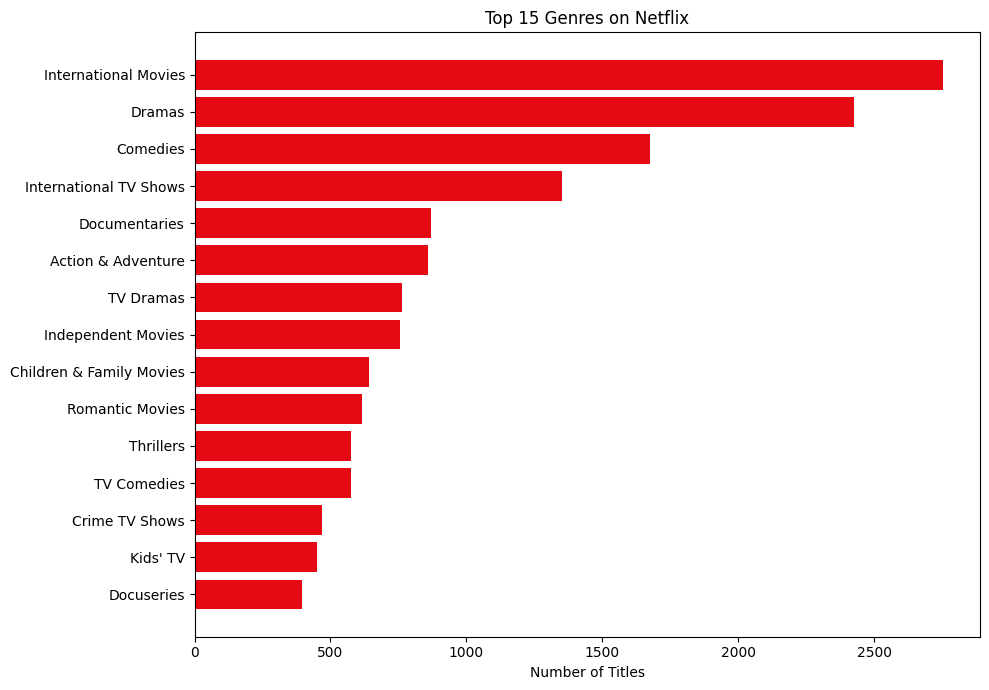

In [28]:
top_genres = genre_df['genre'].value_counts().head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_genres.index, top_genres.values, color='#E50914')
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/chart4_top_genres.png', bbox_inches='tight', dpi=150)
plt.show()

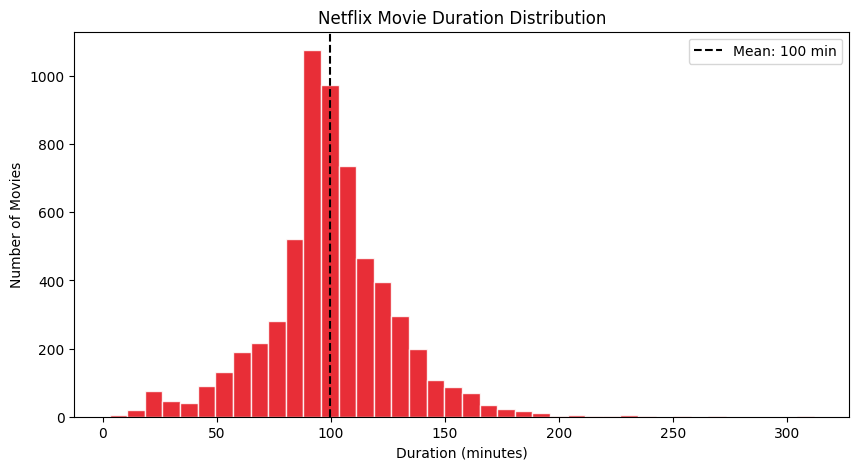

In [29]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10, 5))
plt.hist(movies['duration_min'].dropna(), bins=40, color='#E50914', edgecolor='white', alpha=0.85)
plt.axvline(movies['duration_min'].mean(), color='black', linestyle='--', 
            label=f"Mean: {movies['duration_min'].mean():.0f} min")
plt.title('Netflix Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.legend()
plt.savefig('images/chart5_duration_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

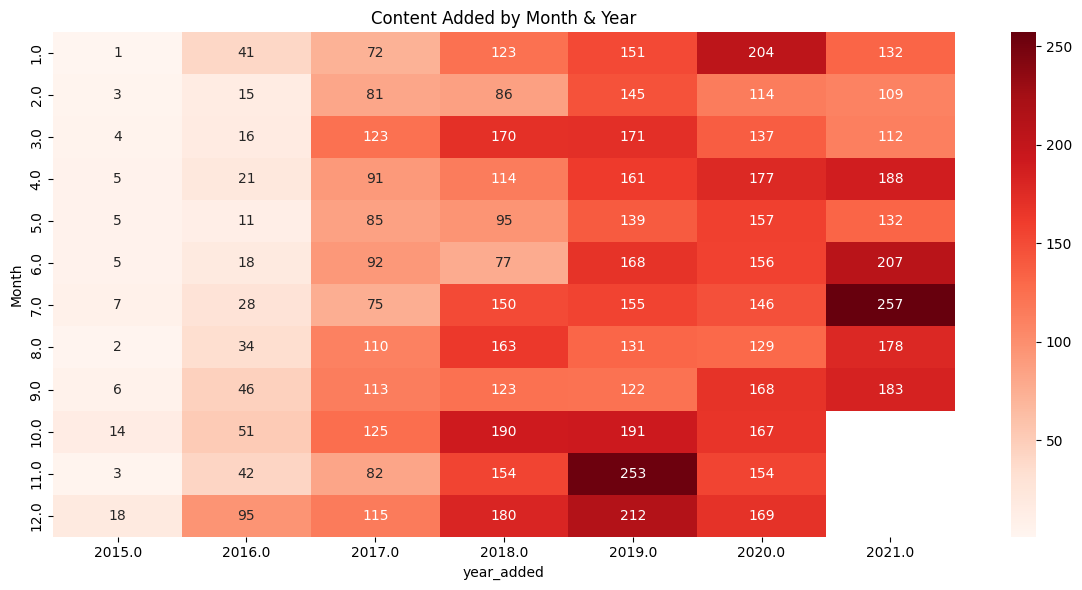

In [31]:
pivot = df.pivot_table(index='month_added', columns='year_added', 
                       values='show_id', aggfunc='count')

pivot = pivot[[c for c in pivot.columns if 2015 <= c <= 2021]]

plt.figure(figsize=(12, 6))
import seaborn as sns
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.0f')
plt.title('Content Added by Month & Year')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig('images/chart6_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## Key Findings

1. **Netflix is 70% Movies, 30% TV Shows** — movies dominate the catalog
2. **Explosive growth from 2016–2019** — Netflix added content aggressively
3. **COVID dip in 2020–2021** — production halts hit the catalog hard
4. **USA dominates at 3000+ titles** — but India at #2 shows Netflix's global push
5. **International Movies is the #1 genre** — Netflix is not just Hollywood anymore
6. **Average movie length is ~99 minutes** — sweet spot is 87–114 minutes

In [22]:
top_directors = (df[df['director'] != 'Unknown']
                 ['director'].value_counts().head(10))
print(top_directors)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


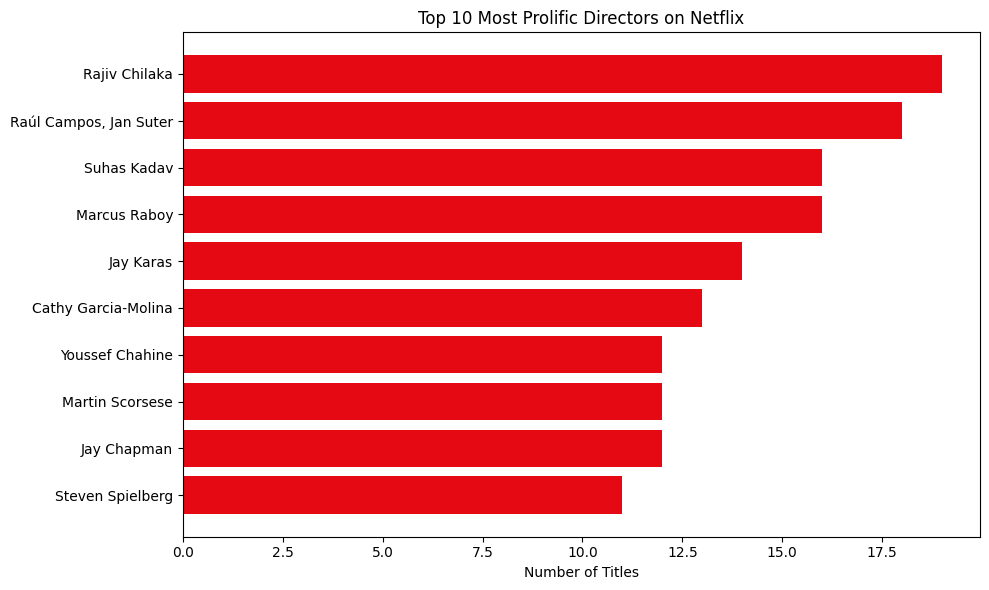

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(top_directors.index, top_directors.values, color='#E50914')
plt.title('Top 10 Most Prolific Directors on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

7. **Rajiv Chilaka is Netflix's most prolific director with 19 titles** — 
beating Scorsese and Spielberg, proving India's massive content contribution